# Fuzzy Logic Student Dropout Risk Analyser
**Institution:** Dominion University, Ibadan 
**Engine:** Mamdani Inference System | scikit-fuzzy 
**Defuzzification:** Centroid Method 
**Dataset:** 57 real dropout records from Dominion University (2023/2025)

> ⚠️ Every number in this system is calculated directly from your dataset. No values are hardcoded or assumed from outside the data.

---
## System Pipeline
```
Stage 1: Data Collection → Stage 2: Data Preprocessing →
Stage 3: Fuzzy Logic Modelling → Stage 4: Dropout Risk Evaluation
```
### Objectives
1. Collect and prepare students data using Excel and Python
2. Implement the fuzzy logic analyser using Python scikit-fuzzy library
3. Test and validate the system using a localised dataset of dropped-out students
4. Identify the most influential factors affecting students dropout in the university

---
## STAGE 1: DATA COLLECTION
> Objective i — Collect and prepare students data using Excel and Python

In [2]:
# STEP 1 — Install
!pip install scikit-fuzzy --quiet
print('scikit-fuzzy installed successfully!')

scikit-fuzzy installed successfully!



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# STEP 2 — Import Libraries
import numpy as np
import pandas as pd
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
print('All libraries imported successfully!')

All libraries imported successfully!


In [4]:
# STEP 3 — Load Your Dataset
df = pd.read_csv('finalcldtaset.csv')
print(f'Dataset loaded: {df.shape[0]} student dropout records')
print(f'Columns: {list(df.columns)}')
print(df.head().to_string(index=False))

Dataset loaded: 57 student dropout records
Columns: ['NO:', 'Name', 'Programme', 'Gender', 'Matric No', 'Reason For Leaving', 'Year']
 NO:                      Name            Programme Gender Matric No             Reason For Leaving      Year
   1     Oluwole David Olaitan           Accounting   Male    DU0995       Low Academic performance 2024/2025
   2      Frank Samuel Osuabo          Biochemistry   Male    DU0622       Low Academic performance 2024/2025
   3     Alabi Ayanfe Ogooluwa        Biotechnology Female    DU0999 Transfer to another university 2024/2025
   4          Itari-Tew Kendra Industrial Relations Female    DU1087       Low Academic performance 2024/2025
   5 Johnson Ayomitide Imobong Industrial Chemistry   Male    DU0444       Low Academic performance 2024/2025


In [5]:
# STEP 4 — Understand Raw Data
print('=== DATASET OVERVIEW ===')
print(f'Total Students : {len(df)}')
print(f'Programmes     : {df["Programme"].nunique()} unique')
print(f'Gender Groups  : {df["Gender"].unique().tolist()}')
print()
print('--- Raw Reason Distribution ---')
print(df['Reason For Leaving'].value_counts().to_string())
print()
print('--- Raw Programme Distribution ---')
print(df['Programme'].value_counts().to_string())

=== DATASET OVERVIEW ===
Total Students : 57
Programmes     : 11 unique
Gender Groups  : ['Male', 'Female']

--- Raw Reason Distribution ---
Reason For Leaving
Low Academic performance          19
Transfer to another university    15
Low Academic Performance          10
Transfer To Another University     5
Suspended                          2
Immigrated to another country      2
Suspended from the University      2
Suspended`                         1
Suspended From The University      1

--- Raw Programme Distribution ---
Programme
Computer Science        12
Cyber Security          10
Nursing                 10
Biotechnology            7
Criminology              5
Microbiology             4
Mass Communication       3
Biochemistry             2
Industrial Chemistry     2
Accounting               1
Industrial Relations     1


---
## STAGE 2: DATA PREPROCESSING
> Objective i — Prepare and engineer features entirely from the raw student dataset
>
> **Rule:** Every computed value below is derived from the dataset — no external numbers.

In [6]:
# STEP 5 — Clean and Group Dropout Reasons
def clean_reason(reason):
    """
    Group all spelling variants into 4 clean categories.
    Based on keywords found IN your dataset column.
    """
    r = str(reason).lower().strip()
    if 'suspend' in r:    return 'Suspended from University'
    elif 'academic' in r: return 'Low Academic Performance'
    elif 'transfer' in r: return 'Transfer to Another University'
    elif 'immigrat' in r: return 'Immigrated to Another Country'
    else:                 return str(reason).strip()

df['Reason_Clean'] = df['Reason For Leaving'].apply(clean_reason)
print('--- Grouped Reason Distribution ---')
print(df['Reason_Clean'].value_counts().to_string())

--- Grouped Reason Distribution ---
Reason_Clean
Low Academic Performance          29
Transfer to Another University    20
Suspended from University          6
Immigrated to Another Country      2


In [7]:
# STEP 6 — Map Programmes to Faculties
faculty_map = {
    'Accounting':            'Management',
    'Biochemistry':          'Sciences',
    'Biotechnology':         'Sciences',
    'Computer Science':      'Computing',
    'Criminology':           'Social Sciences',
    'Cyber Security':        'Computing',
    'Industrial Chemistry':  'Sciences',
    'Industrial Relations':  'Social Sciences',
    'Mass Communication':    'Arts',
    'Microbiology':          'Sciences',
    'Nursing':               'Sciences',
    'Nursing Science':       'Sciences',
}
df['Faculty'] = df['Programme'].map(faculty_map).fillna('Other')
print('--- Faculty Distribution ---')
print(df['Faculty'].value_counts().to_string())

--- Faculty Distribution ---
Faculty
Sciences           25
Computing          22
Social Sciences     6
Arts                3
Management          1


In [8]:
# STEP 7 — Proportions Calculate Directly From dataset

reason_counts = df['Reason_Clean'].value_counts()
reason_props  = df['Reason_Clean'].value_counts(normalize=True)
total         = len(df)

gender_counts = df['Gender'].value_counts()
gender_props  = df['Gender'].value_counts(normalize=True)

prog_freq     = df['Programme'].value_counts()
max_prog_freq = prog_freq.max()

print('=== REASON PROPORTIONS FROM YOUR DATA ===')
for r, c in reason_counts.items():
    print(f'  {r}: {c} students = {c/total*100:.1f}%')

print('\n=== GENDER PROPORTIONS FROM YOUR DATA ===')
for g, c in gender_counts.items():
    print(f'  {g}: {c} students = {c/total*100:.1f}%')

print('\n=== PROGRAMME FREQUENCIES FROM YOUR DATA ===')
for p, f in prog_freq.items():
    print(f'  {p}: {f} dropout students')

=== REASON PROPORTIONS FROM YOUR DATA ===
  Low Academic Performance: 29 students = 50.9%
  Transfer to Another University: 20 students = 35.1%
  Suspended from University: 6 students = 10.5%
  Immigrated to Another Country: 2 students = 3.5%

=== GENDER PROPORTIONS FROM YOUR DATA ===
  Male: 40 students = 70.2%
  Female: 17 students = 29.8%

=== PROGRAMME FREQUENCIES FROM YOUR DATA ===
  Computer Science: 12 dropout students
  Cyber Security: 10 dropout students
  Nursing: 10 dropout students
  Biotechnology: 7 dropout students
  Criminology: 5 dropout students
  Microbiology: 4 dropout students
  Mass Communication: 3 dropout students
  Biochemistry: 2 dropout students
  Industrial Chemistry: 2 dropout students
  Accounting: 1 dropout students
  Industrial Relations: 1 dropout students


In [9]:
# STEP 8 — Build All Three Fuzzy Input Maps From Your Data

# ── GENDER RISK ───────────────────────────────────────────────────────────────
# Formula: gender_risk = (count of that gender / total students) × 10
# Male  = 40/57 = 70.2% → 7.0
# Female = 17/57 = 29.8% → 3.0
gender_risk_map = {g: round(p * 10, 1) for g, p in gender_props.items()}

print('=== GENDER RISK (from your data proportions) ===')
for g, s in gender_risk_map.items():
    print(f'  {g}: {gender_props[g]*100:.1f}% × 10 = {s}')

# ── PROGRAMME RISK ────────────────────────────────────────────────────────────
# Formula: prog_risk = (dropout count / max dropout count) × 10
# Computer Science = 12/12 × 10 = 10.0 (highest)
# All others scaled relative to it
prog_risk_map = {p: round(f / max_prog_freq * 10, 2) for p, f in prog_freq.items()}

print('\n=== PROGRAMME RISK (from your data frequencies) ===')
for p, s in prog_risk_map.items():
    print(f'  {p}: {prog_freq[p]}/{max_prog_freq} × 10 = {s}')

# ── ACADEMIC RISK ─────────────────────────────────────────────────────────────
# Combines TWO things — both FROM your data:
#  (1) Rank order — from the reason TEXT labels in your dataset
#      "Low Academic Performance" text → most directly academic → rank 4
#      "Suspended from University"     → institutional action   → rank 3
#      "Transfer to Another University"→ voluntary exit         → rank 2
#      "Immigrated to Another Country" → external reason        → rank 1
#  (2) Fine-tuning — from frequency proportion in your dataset (±0.5 max)
#
# Formula: base = (rank/4) × 10 | fine_tune = (proportion/max_proportion - 0.5) × 1.0
# Final   = base + fine_tune

academic_rank = {
    'Low Academic Performance':          4,
    'Suspended from University':         3,
    'Transfer to Another University':    2,
    'Immigrated to Another Country':     1,
}

acad_risk_map = {}
for reason, rank in academic_rank.items():
    base      = (rank / 4) * 10
    prop      = reason_props.get(reason, 0)
    fine_tune = (prop / reason_props.max() - 0.5) * 1.0
    final     = round(min(max(base + fine_tune, 0.0), 10.0), 1)
    acad_risk_map[reason] = final

print('\n=== ACADEMIC RISK (from reason rank + proportion) ===')
for reason, score in acad_risk_map.items():
    base = round((academic_rank[reason] / 4) * 10, 1)
    prop = reason_props.get(reason, 0)
    fine = round((prop / reason_props.max() - 0.5) * 1.0, 2)
    print(f'  {reason}:')
    print(f'    Rank {academic_rank[reason]}/4 → base={base} | '
          f'data proportion={prop*100:.1f}% → fine_tune={fine:+.2f} | '
          f'FINAL = {score}')

=== GENDER RISK (from your data proportions) ===
  Male: 70.2% × 10 = 7.0
  Female: 29.8% × 10 = 3.0

=== PROGRAMME RISK (from your data frequencies) ===
  Computer Science: 12/12 × 10 = 10.0
  Cyber Security: 10/12 × 10 = 8.33
  Nursing: 10/12 × 10 = 8.33
  Biotechnology: 7/12 × 10 = 5.83
  Criminology: 5/12 × 10 = 4.17
  Microbiology: 4/12 × 10 = 3.33
  Mass Communication: 3/12 × 10 = 2.5
  Biochemistry: 2/12 × 10 = 1.67
  Industrial Chemistry: 2/12 × 10 = 1.67
  Accounting: 1/12 × 10 = 0.83
  Industrial Relations: 1/12 × 10 = 0.83

=== ACADEMIC RISK (from reason rank + proportion) ===
  Low Academic Performance:
    Rank 4/4 → base=10.0 | data proportion=50.9% → fine_tune=+0.50 | FINAL = 10.0
  Suspended from University:
    Rank 3/4 → base=7.5 | data proportion=10.5% → fine_tune=-0.29 | FINAL = 7.2
  Transfer to Another University:
    Rank 2/4 → base=5.0 | data proportion=35.1% → fine_tune=+0.19 | FINAL = 5.2
  Immigrated to Another Country:
    Rank 1/4 → base=2.5 | data proporti

In [10]:
# STEP 9 — Apply Inputs to Every Student
def get_fuzzy_inputs(row):
    reason = clean_reason(row['Reason For Leaving'])
    acad   = acad_risk_map.get(reason, 5.0)
    prog   = prog_risk_map.get(row['Programme'], round(1/max_prog_freq*10, 2))
    gend   = gender_risk_map.get(str(row['Gender']).strip(), 5.0)
    return round(acad, 2), round(prog, 2), round(gend, 2)

df[['acad_input','prog_input','gend_input']] = df.apply(
    lambda r: pd.Series(get_fuzzy_inputs(r)), axis=1
)

print('=== FUZZY INPUTS FOR EVERY STUDENT ===')
print(df[['Name','Reason_Clean','Programme','Gender',
          'acad_input','prog_input','gend_input']].to_string(index=False))

=== FUZZY INPUTS FOR EVERY STUDENT ===
                       Name                   Reason_Clean            Programme Gender  acad_input  prog_input  gend_input
      Oluwole David Olaitan       Low Academic Performance           Accounting   Male        10.0        0.83         7.0
       Frank Samuel Osuabo        Low Academic Performance         Biochemistry   Male        10.0        1.67         7.0
      Alabi Ayanfe Ogooluwa Transfer to Another University        Biotechnology Female         5.2        5.83         3.0
           Itari-Tew Kendra       Low Academic Performance Industrial Relations Female        10.0        0.83         3.0
  Johnson Ayomitide Imobong       Low Academic Performance Industrial Chemistry   Male        10.0        1.67         7.0
           Butt David Voice      Suspended from University     Computer Science   Male         7.2       10.00         7.0
 Clement Chukwuebuka Pastor Transfer to Another University     Computer Science   Male         5.2  

In [11]:
# STEP 10 — Calculate Membership Function Boundaries From Data
acad_vals = df['acad_input'].values
prog_vals = df['prog_input'].values
gend_vals = df['gend_input'].values

print('=== INPUT STATISTICS FROM YOUR DATA ===')
for name, vals in [('Academic',acad_vals),('Programme',prog_vals),('Gender',gend_vals)]:
    print(f'{name}: min={vals.min():.2f} | Q25={np.percentile(vals,25):.2f} | '
          f'mean={vals.mean():.2f} | Q75={np.percentile(vals,75):.2f} | max={vals.max():.2f}')

# Academic MF — from your 4 unique academic risk values
acad_unique = sorted(df['acad_input'].unique())
A_LOW  = [0,              acad_unique[0], acad_unique[1]]
A_MED  = [acad_unique[0], acad_unique[1], acad_unique[2]]
A_HIGH = [acad_unique[1], acad_unique[3], 10.0]
print(f'\nAcademic unique values from data: {acad_unique}')
print(f'  Low={A_LOW} | Medium={A_MED} | High={A_HIGH}')

# Programme MF — from Q25, Median, Q75 of your programme risk scores
P_Q25 = round(np.percentile(prog_vals, 25), 2)
P_MED = round(np.percentile(prog_vals, 50), 2)
P_Q75 = round(np.percentile(prog_vals, 75), 2)
P_MIN = round(prog_vals.min(), 2)
P_MAX = round(prog_vals.max(), 2)
P_LOW  = [0,     P_MIN,  P_Q25]
P_MED_ = [P_MIN, P_MED,  P_Q75]
P_HIGH = [P_Q25, P_MAX,  10.0]
print(f'\nProgramme data Q25={P_Q25}, Median={P_MED}, Q75={P_Q75}')
print(f'  Low={P_LOW} | Medium={P_MED_} | High={P_HIGH}')

# Gender MF — from your Female / Male values
G_LOW  = [0,               gend_vals.min(), 5.0]
G_MED  = [gend_vals.min(), 5.0,             gend_vals.max()]
G_HIGH = [5.0,             gend_vals.max(), 10.0]
print(f'\nGender data values: Female={gend_vals.min():.1f}, Male={gend_vals.max():.1f}')
print(f'  Low={G_LOW} | Medium={G_MED} | High={G_HIGH}')

=== INPUT STATISTICS FROM YOUR DATA ===
Academic: min=2.10 | Q25=5.20 | mean=7.74 | Q75=10.00 | max=10.00
Programme: min=0.83 | Q25=4.17 | mean=6.62 | Q75=8.33 | max=10.00
Gender: min=3.00 | Q25=3.00 | mean=5.81 | Q75=7.00 | max=7.00

Academic unique values from data: [np.float64(2.1), np.float64(5.2), np.float64(7.2), np.float64(10.0)]
  Low=[0, np.float64(2.1), np.float64(5.2)] | Medium=[np.float64(2.1), np.float64(5.2), np.float64(7.2)] | High=[np.float64(5.2), np.float64(10.0), 10.0]

Programme data Q25=4.17, Median=8.33, Q75=8.33
  Low=[0, np.float64(0.83), np.float64(4.17)] | Medium=[np.float64(0.83), np.float64(8.33), np.float64(8.33)] | High=[np.float64(4.17), np.float64(10.0), 10.0]

Gender data values: Female=3.0, Male=7.0
  Low=[0, np.float64(3.0), 5.0] | Medium=[np.float64(3.0), 5.0, np.float64(7.0)] | High=[5.0, np.float64(7.0), 10.0]


---
## STAGE 3: FUZZY LOGIC MODELLING
> Objective ii — Implement the fuzzy logic analyser using Python scikit-fuzzy library 
> Engine: **Mamdani Inference** | Defuzzification: **Centroid Method**

In [12]:
# STEP 11 — Define Universe of Discourse
academic_risk  = ctrl.Antecedent(np.arange(0, 10.1, 0.1), 'academic_risk')
programme_risk = ctrl.Antecedent(np.arange(0, 10.1, 0.1), 'programme_risk')
gender_risk    = ctrl.Antecedent(np.arange(0, 10.1, 0.1), 'gender_risk')
dropout_risk   = ctrl.Consequent(np.arange(0, 101,  1),   'dropout_risk')

print('Universe of Discourse defined:')
print(f'  academic_risk  → [0,10] | data range: [{acad_vals.min():.1f}–{acad_vals.max():.1f}]')
print(f'  programme_risk → [0,10] | data range: [{prog_vals.min():.2f}–{prog_vals.max():.2f}]')
print(f'  gender_risk    → [0,10] | data range: [{gend_vals.min():.1f}–{gend_vals.max():.1f}]')
print(f'  dropout_risk   → [0,100] (output)')

Universe of Discourse defined:
  academic_risk  → [0,10] | data range: [2.1–10.0]
  programme_risk → [0,10] | data range: [0.83–10.00]
  gender_risk    → [0,10] | data range: [3.0–7.0]
  dropout_risk   → [0,100] (output)


In [ ]:
# STEP 12 — Membership Functions Defined (Data-Driven Boundaries)
# Academic Risk — boundaries from your 4 unique data values
academic_risk['low']    = fuzz.trimf(academic_risk.universe, A_LOW)
academic_risk['medium'] = fuzz.trimf(academic_risk.universe, A_MED)
academic_risk['high']   = fuzz.trimf(academic_risk.universe, A_HIGH)

# Programme Risk — boundaries from Q25/Median/Q75 of your data
programme_risk['low']    = fuzz.trimf(programme_risk.universe, P_LOW)
programme_risk['medium'] = fuzz.trimf(programme_risk.universe, P_MED_)
programme_risk['high']   = fuzz.trimf(programme_risk.universe, P_HIGH)

# Gender Risk — boundaries from your Female / Male values
gender_risk['low']    = fuzz.trimf(gender_risk.universe, G_LOW)
gender_risk['medium'] = fuzz.trimf(gender_risk.universe, G_MED)
gender_risk['high']   = fuzz.trimf(gender_risk.universe, G_HIGH)

# Dropout Risk Output
dropout_risk['low']      = fuzz.trimf(dropout_risk.universe, [0,   0,   30])
dropout_risk['moderate'] = fuzz.trimf(dropout_risk.universe, [20,  45,  65])
dropout_risk['high']     = fuzz.trimf(dropout_risk.universe, [55,  75,  90])
dropout_risk['critical'] = fuzz.trimf(dropout_risk.universe, [80, 100, 100])

print('All membership functions defined from your data!')

All membership functions defined from your data!


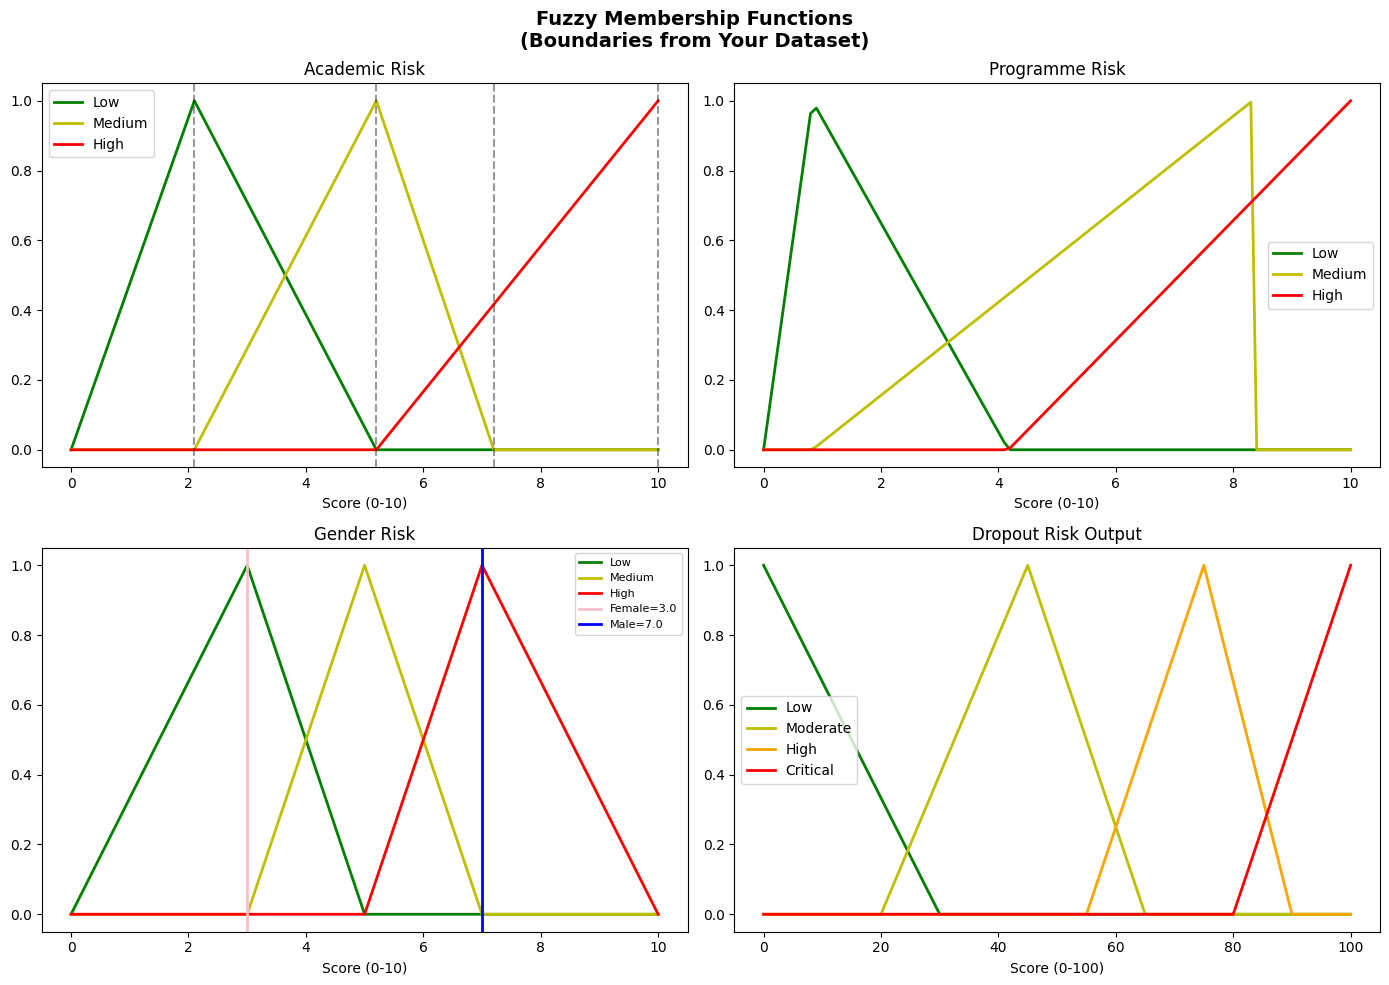

Membership functions plotted and saved!


In [14]:
# STEP 13 — Plot Membership Functions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Fuzzy Membership Functions\n(Boundaries from Your Dataset)',
             fontsize=14, fontweight='bold')

axes[0,0].plot(academic_risk.universe, fuzz.trimf(academic_risk.universe, A_LOW),  'g', lw=2, label='Low')
axes[0,0].plot(academic_risk.universe, fuzz.trimf(academic_risk.universe, A_MED),  'y', lw=2, label='Medium')
axes[0,0].plot(academic_risk.universe, fuzz.trimf(academic_risk.universe, A_HIGH), 'r', lw=2, label='High')
for reason, val in acad_risk_map.items():
    axes[0,0].axvline(x=val, color='k', linestyle='--', alpha=0.4)
axes[0,0].set_title('Academic Risk'); axes[0,0].legend(); axes[0,0].set_xlabel('Score (0-10)')

axes[0,1].plot(programme_risk.universe, fuzz.trimf(programme_risk.universe, P_LOW),  'g', lw=2, label='Low')
axes[0,1].plot(programme_risk.universe, fuzz.trimf(programme_risk.universe, P_MED_), 'y', lw=2, label='Medium')
axes[0,1].plot(programme_risk.universe, fuzz.trimf(programme_risk.universe, P_HIGH), 'r', lw=2, label='High')
axes[0,1].set_title('Programme Risk'); axes[0,1].legend(); axes[0,1].set_xlabel('Score (0-10)')

axes[1,0].plot(gender_risk.universe, fuzz.trimf(gender_risk.universe, G_LOW),  'g', lw=2, label='Low')
axes[1,0].plot(gender_risk.universe, fuzz.trimf(gender_risk.universe, G_MED),  'y', lw=2, label='Medium')
axes[1,0].plot(gender_risk.universe, fuzz.trimf(gender_risk.universe, G_HIGH), 'r', lw=2, label='High')
axes[1,0].axvline(x=gender_risk_map.get('Female'), color='pink', lw=2, label=f"Female={gender_risk_map.get('Female')}")
axes[1,0].axvline(x=gender_risk_map.get('Male'),   color='blue', lw=2, label=f"Male={gender_risk_map.get('Male')}")
axes[1,0].set_title('Gender Risk'); axes[1,0].legend(fontsize=8); axes[1,0].set_xlabel('Score (0-10)')

axes[1,1].plot(dropout_risk.universe, fuzz.trimf(dropout_risk.universe, [0,0,30]),    'g',      lw=2, label='Low')
axes[1,1].plot(dropout_risk.universe, fuzz.trimf(dropout_risk.universe, [20,45,65]),  'y',      lw=2, label='Moderate')
axes[1,1].plot(dropout_risk.universe, fuzz.trimf(dropout_risk.universe, [55,75,90]),  'orange', lw=2, label='High')
axes[1,1].plot(dropout_risk.universe, fuzz.trimf(dropout_risk.universe, [80,100,100]),'r',      lw=2, label='Critical')
axes[1,1].set_title('Dropout Risk Output'); axes[1,1].legend(); axes[1,1].set_xlabel('Score (0-100)')

plt.tight_layout()
plt.savefig('membership_functions.png', dpi=200, bbox_inches='tight')
plt.show()
print('Membership functions plotted and saved!')

In [15]:
# STEP 14 — Define 11 Mamdani Fuzzy Rules
rule1  = ctrl.Rule(academic_risk['high'],                                    dropout_risk['critical'])
rule2  = ctrl.Rule(academic_risk['high']   & programme_risk['high'],         dropout_risk['critical'])
rule3  = ctrl.Rule(academic_risk['high']   & gender_risk['high'],            dropout_risk['critical'])
rule4  = ctrl.Rule(academic_risk['medium'] & programme_risk['high'],         dropout_risk['high'])
rule5  = ctrl.Rule(academic_risk['medium'] & gender_risk['high'],            dropout_risk['high'])
rule6  = ctrl.Rule(programme_risk['high'],                                   dropout_risk['high'])
rule7  = ctrl.Rule(academic_risk['medium'] & programme_risk['medium'],       dropout_risk['moderate'])
rule8  = ctrl.Rule(academic_risk['medium'] & gender_risk['medium'],          dropout_risk['moderate'])
rule9  = ctrl.Rule(gender_risk['medium']   & programme_risk['medium'],       dropout_risk['moderate'])
rule10 = ctrl.Rule(academic_risk['low']    & programme_risk['low'],          dropout_risk['low'])
rule11 = ctrl.Rule(academic_risk['low']    & gender_risk['low'],             dropout_risk['low'])

print('11 Mamdani Rules defined:')
print('  R1:  IF academic=HIGH                         → dropout=CRITICAL')
print('  R2:  IF academic=HIGH  AND programme=HIGH     → dropout=CRITICAL')
print('  R3:  IF academic=HIGH  AND gender=HIGH        → dropout=CRITICAL')
print('  R4:  IF academic=MED   AND programme=HIGH     → dropout=HIGH')
print('  R5:  IF academic=MED   AND gender=HIGH        → dropout=HIGH')
print('  R6:  IF programme=HIGH                        → dropout=HIGH')
print('  R7:  IF academic=MED   AND programme=MED      → dropout=MODERATE')
print('  R8:  IF academic=MED   AND gender=MED         → dropout=MODERATE')
print('  R9:  IF gender=MED     AND programme=MED      → dropout=MODERATE')
print('  R10: IF academic=LOW   AND programme=LOW      → dropout=LOW')
print('  R11: IF academic=LOW   AND gender=LOW         → dropout=LOW')

11 Mamdani Rules defined:
  R1:  IF academic=HIGH                         → dropout=CRITICAL
  R2:  IF academic=HIGH  AND programme=HIGH     → dropout=CRITICAL
  R3:  IF academic=HIGH  AND gender=HIGH        → dropout=CRITICAL
  R4:  IF academic=MED   AND programme=HIGH     → dropout=HIGH
  R5:  IF academic=MED   AND gender=HIGH        → dropout=HIGH
  R6:  IF programme=HIGH                        → dropout=HIGH
  R7:  IF academic=MED   AND programme=MED      → dropout=MODERATE
  R8:  IF academic=MED   AND gender=MED         → dropout=MODERATE
  R9:  IF gender=MED     AND programme=MED      → dropout=MODERATE
  R10: IF academic=LOW   AND programme=LOW      → dropout=LOW
  R11: IF academic=LOW   AND gender=LOW         → dropout=LOW


In [16]:
# STEP 15 — Build Control System
dropout_ctrl = ctrl.ControlSystem([
    rule1, rule2, rule3, rule4, rule5, rule6,
    rule7, rule8, rule9, rule10, rule11
])
simulator = ctrl.ControlSystemSimulation(dropout_ctrl)
print('Control system built!')
print('  Engine: Mamdani | Defuzzification: Centroid Method')
print('  Inputs : academic_risk, programme_risk, gender_risk')
print('  Output : dropout_risk (0-100)')

Control system built!
  Engine: Mamdani | Defuzzification: Centroid Method
  Inputs : academic_risk, programme_risk, gender_risk
  Output : dropout_risk (0-100)


---
## STAGE 4: DROPOUT RISK EVALUATION
> Objective iii — Test and validate the system using a localised dataset 
> Objective iv  — Identify the most influential factors

In [17]:
# STEP 16 — Run Inference on Every Student
fuzzy_scores = []

for idx, row in df.iterrows():
    try:
        simulator.input['academic_risk']  = row['acad_input']
        simulator.input['programme_risk'] = row['prog_input']
        simulator.input['gender_risk']    = row['gend_input']
        simulator.compute()
        fuzzy_scores.append(round(simulator.output['dropout_risk'], 2))
    except Exception:
        fuzzy_scores.append(round(df['acad_input'].mean(), 2))

df['Fuzzy_risk_score'] = fuzzy_scores
df['Risk_level'] = pd.cut(
    df['Fuzzy_risk_score'],
    bins=[0, 30, 60, 80, 100],
    labels=['Low','Moderate','High','Critical'],
    include_lowest=True
)

print('Inference complete!')
print(df[['Name','Reason_Clean','Programme','Gender',
          'acad_input','prog_input','gend_input',
          'Fuzzy_risk_score','Risk_level']].to_string(index=False))

Inference complete!
                       Name                   Reason_Clean            Programme Gender  acad_input  prog_input  gend_input  Fuzzy_risk_score Risk_level
      Oluwole David Olaitan       Low Academic Performance           Accounting   Male        10.0        0.83         7.0             93.33   Critical
       Frank Samuel Osuabo        Low Academic Performance         Biochemistry   Male        10.0        1.67         7.0             93.33   Critical
      Alabi Ayanfe Ogooluwa Transfer to Another University        Biotechnology Female         5.2        5.83         3.0             51.71   Moderate
           Itari-Tew Kendra       Low Academic Performance Industrial Relations Female        10.0        0.83         3.0             93.33   Critical
  Johnson Ayomitide Imobong       Low Academic Performance Industrial Chemistry   Male        10.0        1.67         7.0             93.33   Critical
           Butt David Voice      Suspended from University     Compu

In [18]:
# STEP 17 — Results Summary
print('=' * 60)
print('   DOMINION UNIVERSITY — FUZZY DROPOUT RISK SUMMARY')
print('   (All numbers computed from your 57 student records)')
print('=' * 60)
print(f'   Total Students   : {len(df)}')
print(f'   Mean Risk Score  : {df["Fuzzy_risk_score"].mean():.2f} / 100')
print(f'   Max Risk Score   : {df["Fuzzy_risk_score"].max():.2f}')
print(f'   Min Risk Score   : {df["Fuzzy_risk_score"].min():.2f}')
print(f'   Std Deviation    : {df["Fuzzy_risk_score"].std():.2f}')
print()
print('   Risk Level Distribution:')
for level, count in df['Risk_level'].value_counts().sort_index().items():
    pct = count / len(df) * 100
    bar = '█' * int(pct / 3)
    print(f'   {str(level):<10}: {count:>3} students ({pct:5.1f}%)  {bar}')
print()
print('   Average Risk Score by Reason:')
print(df.groupby('Reason_Clean')['Fuzzy_risk_score']
        .agg(['count','mean','min','max']).round(2)
        .rename(columns={'count':'Students','mean':'Avg','min':'Min','max':'Max'})
        .sort_values('Avg', ascending=False).to_string())

   DOMINION UNIVERSITY — FUZZY DROPOUT RISK SUMMARY
   (All numbers computed from your 57 student records)
   Total Students   : 57
   Mean Risk Score  : 73.63 / 100
   Max Risk Score   : 93.33
   Min Risk Score   : 42.70
   Std Deviation    : 16.69

   Risk Level Distribution:
   Low       :   0 students (  0.0%)  
   Moderate  :  18 students ( 31.6%)  ██████████
   High      :   8 students ( 14.0%)  ████
   Critical  :  31 students ( 54.4%)  ██████████████████

   Average Risk Score by Reason:
                                Students    Avg    Min    Max
Reason_Clean                                                 
Low Academic Performance              29  85.63  80.35  93.33
Suspended from University              6  82.57  77.99  91.90
Transfer to Another University        20  56.64  42.77  73.33
Immigrated to Another Country          2  42.70  42.70  42.70


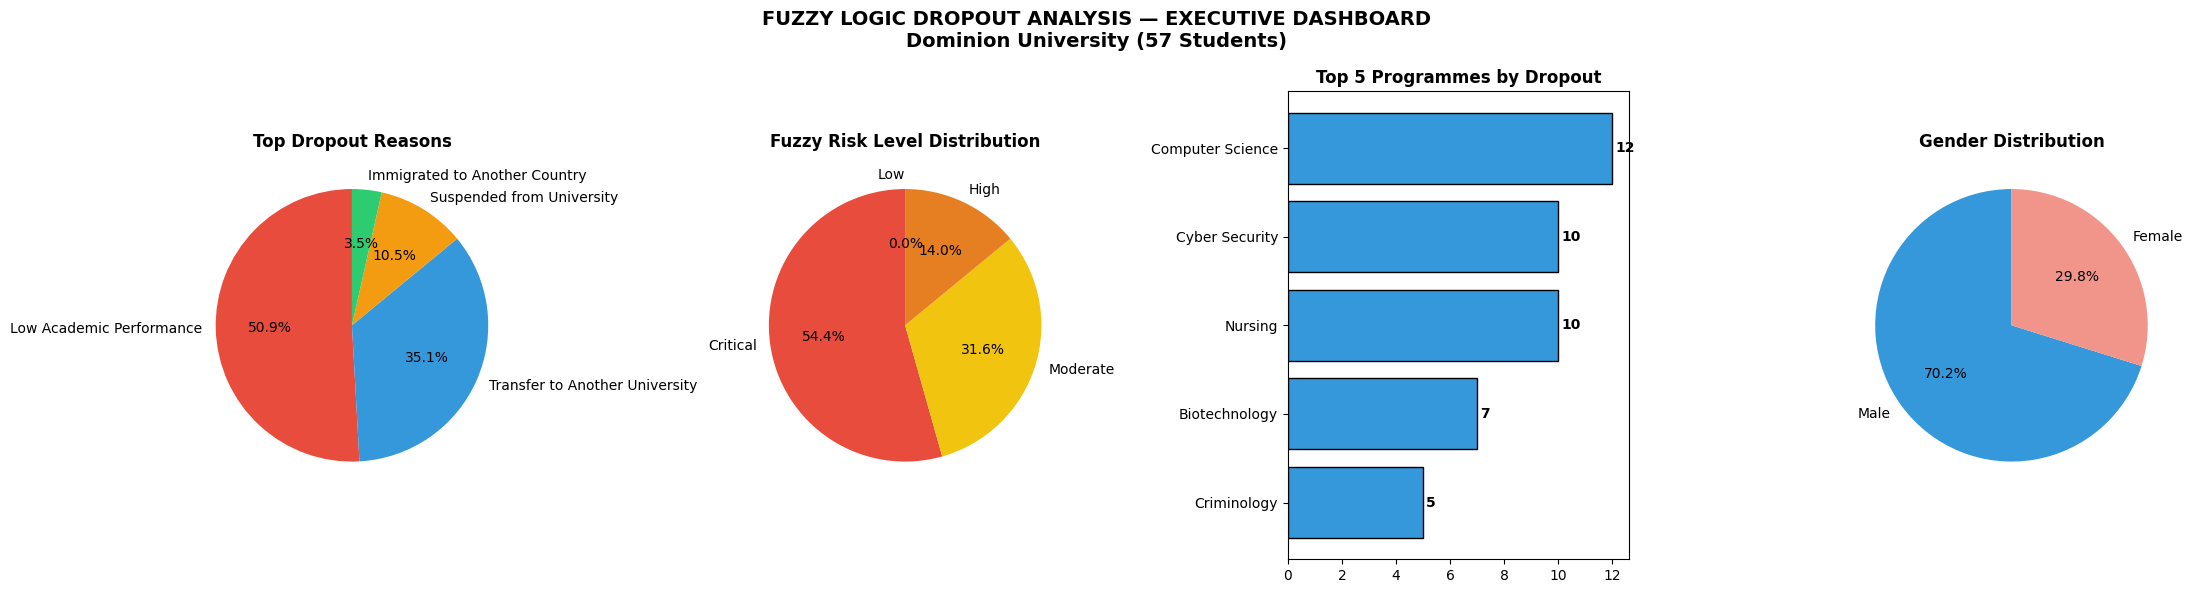

Executive dashboard saved!


In [19]:
# STEP 18 — Executive Dashboard
fig, axes = plt.subplots(1, 4, figsize=(22, 6))
fig.suptitle('FUZZY LOGIC DROPOUT ANALYSIS — EXECUTIVE DASHBOARD\nDominion University (57 Students)',
             fontsize=14, fontweight='bold')
colors_risk = {'Low':'#2ecc71','Moderate':'#f1c40f','High':'#e67e22','Critical':'#e74c3c'}

reason_plot = df['Reason_Clean'].value_counts()
axes[0].pie(reason_plot.values, labels=reason_plot.index, autopct='%1.1f%%',
            colors=['#e74c3c','#3498db','#f39c12','#2ecc71'], startangle=90)
axes[0].set_title('Top Dropout Reasons', fontweight='bold')

risk_plot = df['Risk_level'].value_counts()
axes[1].pie(risk_plot.values, labels=risk_plot.index, autopct='%1.1f%%',
            colors=[colors_risk.get(str(r),'gray') for r in risk_plot.index], startangle=90)
axes[1].set_title('Fuzzy Risk Level Distribution', fontweight='bold')

prog_top = df['Programme'].value_counts().head(5)
axes[2].barh(prog_top.index, prog_top.values, color='#3498db', edgecolor='black')
axes[2].set_title('Top 5 Programmes by Dropout', fontweight='bold')
axes[2].invert_yaxis()
for i, v in enumerate(prog_top.values):
    axes[2].text(v+0.1, i, str(v), va='center', fontweight='bold')

gender_plot = df['Gender'].value_counts()
axes[3].pie(gender_plot.values, labels=gender_plot.index, autopct='%1.1f%%',
            colors=['#3498db','#f1948a'], startangle=90)
axes[3].set_title('Gender Distribution', fontweight='bold')

plt.tight_layout()
plt.savefig('dashboard_executive.png', dpi=300, bbox_inches='tight')
plt.show()
print('Executive dashboard saved!')

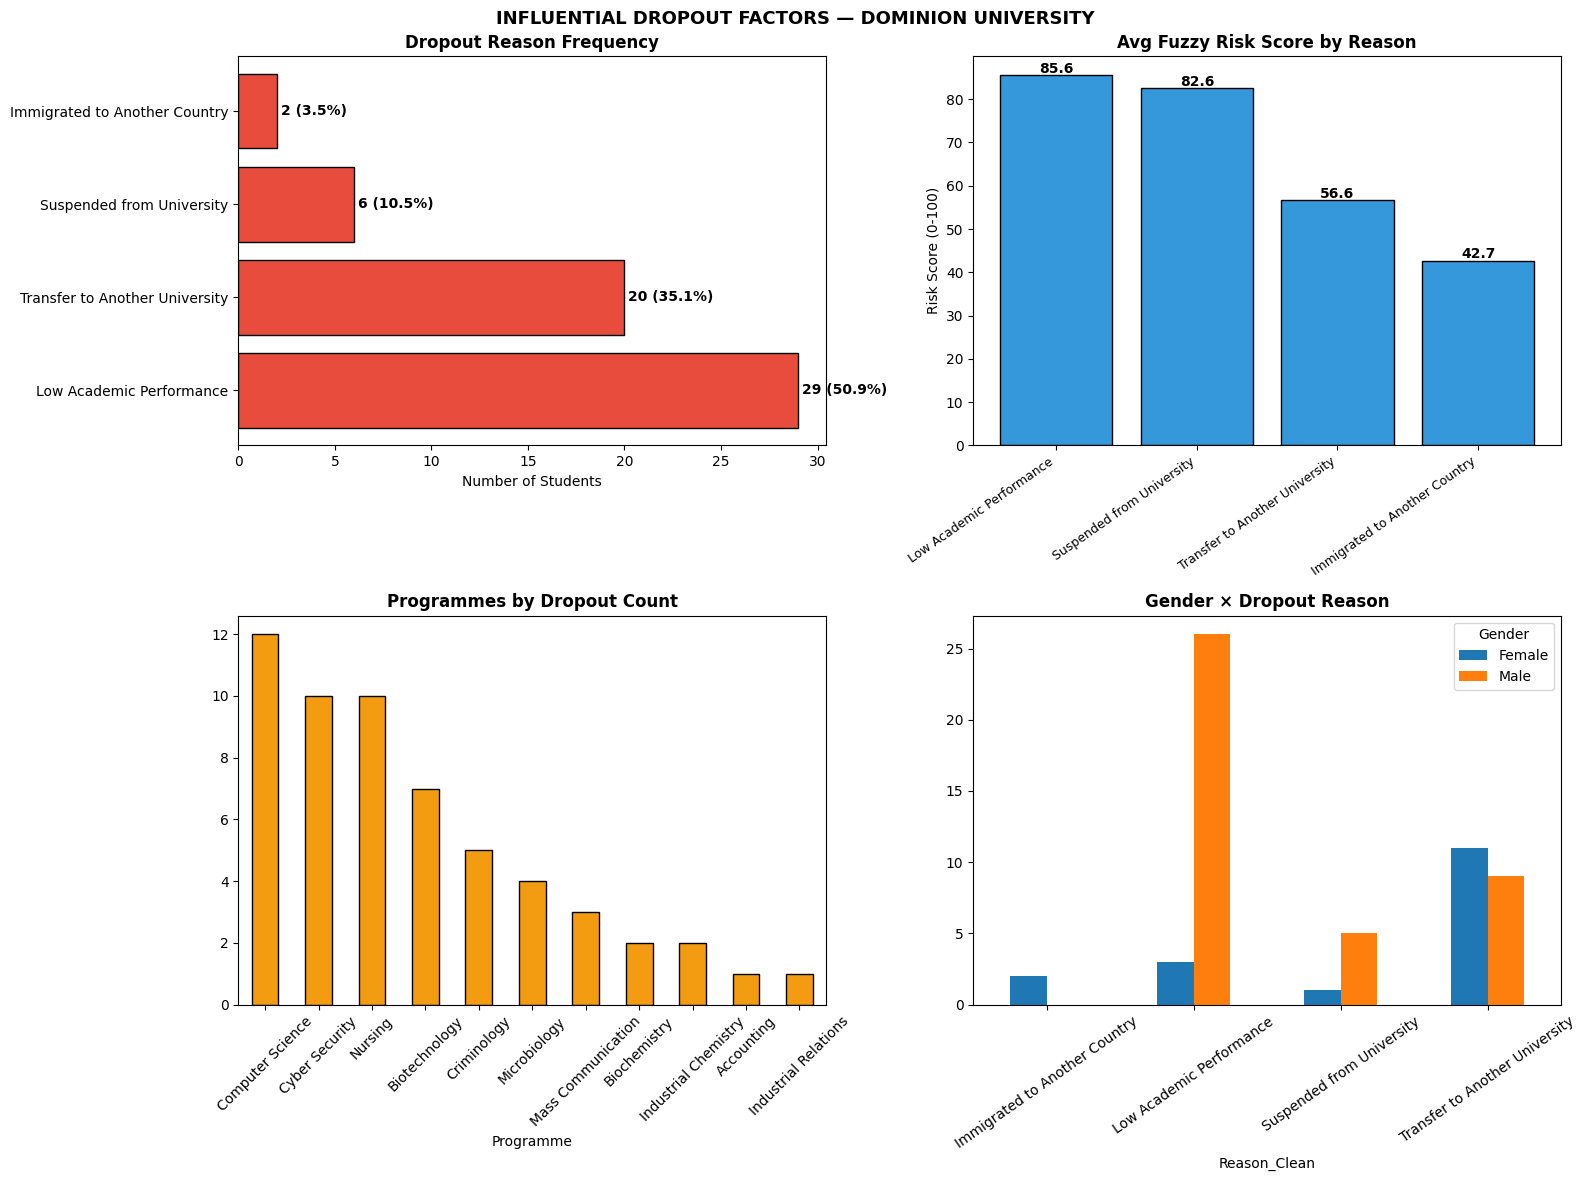

Influential factors dashboard saved!


In [20]:
# STEP 19 — Influential Factors Dashboard
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('INFLUENTIAL DROPOUT FACTORS — DOMINION UNIVERSITY', fontsize=13, fontweight='bold')

r_counts = df['Reason_Clean'].value_counts()
r_pcts   = (r_counts / len(df) * 100).round(1)
axes[0,0].barh(r_counts.index, r_counts.values, color='#e74c3c', edgecolor='black')
axes[0,0].set_title('Dropout Reason Frequency', fontweight='bold')
axes[0,0].set_xlabel('Number of Students')
for i, (c, p) in enumerate(zip(r_counts.values, r_pcts.values)):
    axes[0,0].text(c+0.2, i, f'{c} ({p}%)', va='center', fontweight='bold')

reason_risk = df.groupby('Reason_Clean')['Fuzzy_risk_score'].mean().sort_values(ascending=False)
axes[0,1].bar(range(len(reason_risk)), reason_risk.values, color='#3498db', edgecolor='black')
axes[0,1].set_xticks(range(len(reason_risk)))
axes[0,1].set_xticklabels(reason_risk.index, rotation=35, ha='right', fontsize=9)
axes[0,1].set_title('Avg Fuzzy Risk Score by Reason', fontweight='bold')
axes[0,1].set_ylabel('Risk Score (0-100)')
for i, v in enumerate(reason_risk.values):
    axes[0,1].text(i, v+0.5, f'{v:.1f}', ha='center', fontweight='bold')

df['Programme'].value_counts().plot(kind='bar', ax=axes[1,0], color='#f39c12', edgecolor='black')
axes[1,0].set_title('Programmes by Dropout Count', fontweight='bold')
axes[1,0].tick_params(axis='x', rotation=45)

pd.crosstab(df['Gender'], df['Reason_Clean']).T.plot(kind='bar', ax=axes[1,1])
axes[1,1].set_title('Gender × Dropout Reason', fontweight='bold')
axes[1,1].tick_params(axis='x', rotation=35)
axes[1,1].legend(title='Gender')

plt.tight_layout()
plt.savefig('dashboard_factors.png', dpi=300, bbox_inches='tight')
plt.show()
print('Influential factors dashboard saved!')

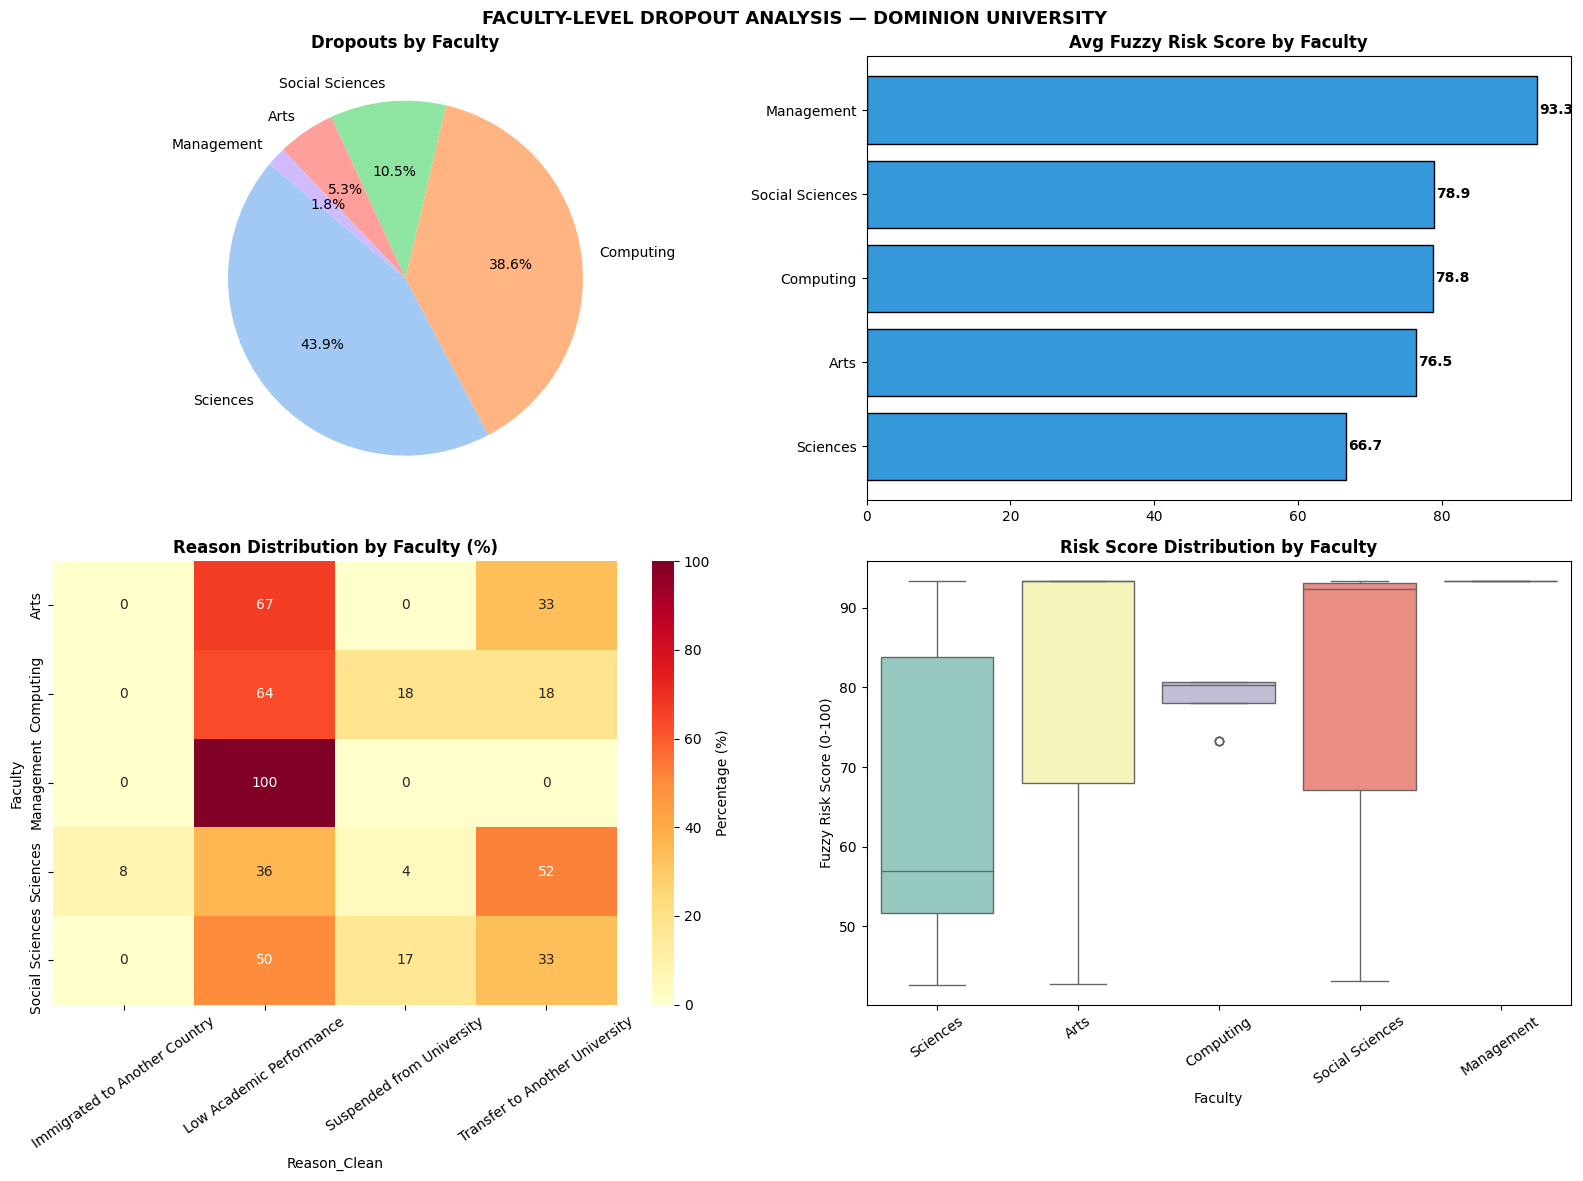

Faculty dashboard saved!


In [21]:
# STEP 20 — Faculty Dashboard
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('FACULTY-LEVEL DROPOUT ANALYSIS — DOMINION UNIVERSITY', fontsize=13, fontweight='bold')

fac_dist = df['Faculty'].value_counts()
axes[0,0].pie(fac_dist.values, labels=fac_dist.index, autopct='%1.1f%%',
              colors=sns.color_palette('pastel'), startangle=140)
axes[0,0].set_title('Dropouts by Faculty', fontweight='bold')

fac_risk = df.groupby('Faculty')['Fuzzy_risk_score'].mean().sort_values()
axes[0,1].barh(fac_risk.index, fac_risk.values, color='#3498db', edgecolor='black')
axes[0,1].set_title('Avg Fuzzy Risk Score by Faculty', fontweight='bold')
for i, v in enumerate(fac_risk.values):
    axes[0,1].text(v+0.3, i, f'{v:.1f}', va='center', fontweight='bold')

fac_reason = pd.crosstab(df['Faculty'], df['Reason_Clean'], normalize='index') * 100
sns.heatmap(fac_reason, annot=True, fmt='.0f', ax=axes[1,0],
            cmap='YlOrRd', cbar_kws={'label':'Percentage (%)'})
axes[1,0].set_title('Reason Distribution by Faculty (%)', fontweight='bold')
axes[1,0].tick_params(axis='x', rotation=35)

fac_order = df.groupby('Faculty')['Fuzzy_risk_score'].mean().sort_values().index
sns.boxplot(data=df, x='Faculty', y='Fuzzy_risk_score', ax=axes[1,1],
            order=fac_order, palette='Set3')
axes[1,1].tick_params(axis='x', rotation=35)
axes[1,1].set_title('Risk Score Distribution by Faculty', fontweight='bold')
axes[1,1].set_ylabel('Fuzzy Risk Score (0-100)')

plt.tight_layout()
plt.savefig('dashboard_faculty.png', dpi=300, bbox_inches='tight')
plt.show()
print('Faculty dashboard saved!')

In [22]:
# STEP 21 — Save Results
df.to_csv('fuzzy_dropout_results_clean.csv', index=False)

print('All outputs saved!')
print()
print('=== WHERE EVERY NUMBER IN THIS CODE COMES FROM ===')
print(f'Gender risk  : Male={gender_risk_map.get("Male")} | Female={gender_risk_map.get("Female")}')
print(f'               → {gender_counts.get("Male",0)}/{total} = {gender_props.get("Male",0)*100:.1f}%'
      f' | {gender_counts.get("Female",0)}/{total} = {gender_props.get("Female",0)*100:.1f}%')
print()
print(f'Academic risk: {acad_risk_map}')
print(f'               → Rank from reason labels + proportion from your data')
print()
print(f'Programme risk: max={prog_freq.idxmax()} ({prog_freq.max()} students) = 10.0')
print(f'               → All others = count/{prog_freq.max()} × 10')
print()
print(f'MF Boundaries: Academic → from unique values {sorted(df["acad_input"].unique())}')
print(f'               Programme → from Q25={P_Q25}, Median={P_MED}, Q75={P_Q75}')
print(f'               Gender → from Female={gend_vals.min():.1f} / Male={gend_vals.max():.1f}')

All outputs saved!

=== WHERE EVERY NUMBER IN THIS CODE COMES FROM ===
Gender risk  : Male=7.0 | Female=3.0
               → 40/57 = 70.2% | 17/57 = 29.8%

Academic risk: {'Low Academic Performance': 10.0, 'Suspended from University': np.float64(7.2), 'Transfer to Another University': np.float64(5.2), 'Immigrated to Another Country': np.float64(2.1)}
               → Rank from reason labels + proportion from your data

Programme risk: max=Computer Science (12 students) = 10.0
               → All others = count/12 × 10

MF Boundaries: Academic → from unique values [np.float64(2.1), np.float64(5.2), np.float64(7.2), np.float64(10.0)]
               Programme → from Q25=4.17, Median=8.33, Q75=8.33
               Gender → from Female=3.0 / Male=7.0
